In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    silhouette_score,
)

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
)
from sklearn.svm import LinearSVC, SVR
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")



complaints_df = pd.read_csv("/kaggle/input/datasets/anubhavsingh311/civicpulse-synthetic-complaints/civicpulse_synthetic_complaints.csv")

print(f"Loaded: {dataset_path}")
print(f"Shape: {complaints_df.shape[0]:,} rows x {complaints_df.shape[1]} columns")
display(complaints_df.head())
complaints_df.info()

Loaded: None
Shape: 10,477 rows x 8 columns


,incident_id,timestamp,category,locality,latitude,longitude,text,status
0,C00049,2026-07-01 07:15:00,Parks / Public Spaces,Sector 8,27.503799,77.669711,Public space requires cleaning,Open
1,C00107,2026-07-01 07:21:00,Street Lights,Ward 9,27.483922,77.664680,The road is dark because the street light failed,Resolved
2,C00084,2026-07-01 07:32:00,Roads & Potholes,Ward 7,27.514315,77.675985,Large pothole near the school,Open
3,C00124,2026-07-01 07:42:00,Street Lights,Ward 11,27.517008,77.690070,The road is dark because the street light failed,Open
4,C00099,2026-07-01 07:42:00,Water Supply,Ward 9,27.487868,77.666598,Water connection is not working,Resolved


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10477 entries, 0 to 10476
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   incident_id  10477 non-null  object 
 1   timestamp    10477 non-null  object 
 2   category     10477 non-null  object 
 3   locality     10477 non-null  object 
 4   latitude     10477 non-null  float64
 5   longitude    10477 non-null  float64
 6   text         10477 non-null  object 
 7   status       10477 non-null  object 
dtypes: float64(2), object(6)
memory usage: 654.9+ KB


In [7]:
complaints_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10477 entries, 0 to 10476
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   incident_id  10477 non-null  object 
 1   timestamp    10477 non-null  object 
 2   category     10477 non-null  object 
 3   locality     10477 non-null  object 
 4   latitude     10477 non-null  float64
 5   longitude    10477 non-null  float64
 6   text         10477 non-null  object 
 7   status       10477 non-null  object 
dtypes: float64(2), object(6)
memory usage: 654.9+ KB


In [8]:
complaints_df.describe(include="all")

,incident_id,timestamp,category,locality,latitude,longitude,text,status
count,10477,10477,10477,10477,10477.000000,10477.000000,10477,10477
unique,10477,9668,9,8,NaN,NaN,68,2
top,C10149,2026-07-02 20:00:00,Water Supply,Sector 12,NaN,NaN,A damaged barrier is creating a safety issue,Open
freq,1,4,1368,1452,NaN,NaN,246,7088
mean,NaN,NaN,NaN,NaN,27.499452,77.678035,NaN,NaN
std,NaN,NaN,NaN,NaN,0.010682,0.008830,NaN,NaN
min,NaN,NaN,NaN,NaN,27.480603,77.660394,NaN,NaN
25%,NaN,NaN,NaN,NaN,27.490026,77.671011,NaN,NaN
50%,NaN,NaN,NaN,NaN,27.498209,77.678456,NaN,NaN
75%,NaN,NaN,NaN,NaN,27.508035,77.687320,NaN,NaN


In [9]:
# Clean and prepare the complaint data
clean_df = complaints_df.copy()

# Standardize column names and text fields
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

text_columns = ["incident_id", "category", "locality", "text", "status"]
for column in text_columns:
    clean_df[column] = clean_df[column].astype("string").str.strip()

# Normalize text values used for grouping and modeling
clean_df["category"] = clean_df["category"].str.replace(r"\s+", " ", regex=True)
clean_df["locality"] = clean_df["locality"].str.replace(r"\s+", " ", regex=True)
clean_df["status"] = clean_df["status"].str.title()
clean_df["text"] = clean_df["text"].str.replace(r"\s+", " ", regex=True)
clean_df["text_clean"] = (
    clean_df["text"]
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Convert dates and coordinates to reliable numeric/datetime types
clean_df["timestamp"] = pd.to_datetime(clean_df["timestamp"], errors="coerce")
clean_df["latitude"] = pd.to_numeric(clean_df["latitude"], errors="coerce")
clean_df["longitude"] = pd.to_numeric(clean_df["longitude"], errors="coerce")

rows_before = len(clean_df)
missing_before = int(clean_df.isna().sum().sum())

# Remove records that cannot support analysis
clean_df = clean_df.drop_duplicates(subset="incident_id", keep="first")
clean_df = clean_df.dropna(subset=["incident_id", "timestamp", "category", "locality", "text_clean"])
clean_df = clean_df[clean_df["text_clean"].str.len() > 0]
clean_df = clean_df[clean_df["latitude"].between(-90, 90)]
clean_df = clean_df[clean_df["longitude"].between(-180, 180)]

# Fill optional fields while keeping missing values visible in the data
clean_df["status"] = clean_df["status"].fillna("Unknown")

# Add analysis-friendly time features
clean_df["date"] = clean_df["timestamp"].dt.date
clean_df["hour"] = clean_df["timestamp"].dt.hour
clean_df["day_of_week"] = clean_df["timestamp"].dt.day_name()
clean_df["day_of_week_num"] = clean_df["timestamp"].dt.dayofweek
clean_df["week"] = clean_df["timestamp"].dt.to_period("W").astype(str)
clean_df["is_open"] = clean_df["status"].eq("Open")

clean_df = clean_df.sort_values("timestamp").reset_index(drop=True)

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {len(clean_df):,}")
print(f"Rows removed:         {rows_before - len(clean_df):,}")
print(f"Missing values before: {missing_before:,}")
print(f"Missing values after:  {int(clean_df.isna().sum().sum()):,}")
print(f"Duplicate incident IDs: {clean_df['incident_id'].duplicated().sum()}")

display(clean_df.head())
display(clean_df[["category", "locality", "status"]].nunique().rename("unique_values").to_frame())

Rows before cleaning: 10,477
Rows after cleaning:  10,477
Rows removed:         0
Missing values before: 0
Missing values after:  0
Duplicate incident IDs: 0


,incident_id,timestamp,category,locality,latitude,longitude,text,status,text_clean,date,hour,day_of_week,day_of_week_num,week,is_open
0,C00049,2026-07-01 07:15:00,Parks / Public Spaces,Sector 8,27.503799,77.669711,Public space requires cleaning,Open,public space requires cleaning,2026-07-01,7,Wednesday,2,2026-06-29/2026-07-05,True
1,C00107,2026-07-01 07:21:00,Street Lights,Ward 9,27.483922,77.664680,The road is dark because the street light failed,Resolved,the road is dark because the street light failed,2026-07-01,7,Wednesday,2,2026-06-29/2026-07-05,False
2,C00084,2026-07-01 07:32:00,Roads & Potholes,Ward 7,27.514315,77.675985,Large pothole near the school,Open,large pothole near the school,2026-07-01,7,Wednesday,2,2026-06-29/2026-07-05,True
3,C00124,2026-07-01 07:42:00,Street Lights,Ward 11,27.517008,77.690070,The road is dark because the street light failed,Open,the road is dark because the street light failed,2026-07-01,7,Wednesday,2,2026-06-29/2026-07-05,True
4,C00099,2026-07-01 07:42:00,Water Supply,Ward 9,27.487868,77.666598,Water connection is not working,Resolved,water connection is not working,2026-07-01,7,Wednesday,2,2026-06-29/2026-07-05,False


,unique_values
category,9
locality,8
status,2


In [10]:
# Quality checks and reusable summaries
quality_report = pd.DataFrame({
    "dtype": clean_df.dtypes.astype(str),
    "missing": clean_df.isna().sum(),
    "missing_percent": (clean_df.isna().mean() * 100).round(2),
    "unique_values": clean_df.nunique(),
})

category_summary = (
    clean_df.groupby("category", as_index=False)
    .agg(
        complaints=("incident_id", "count"),
        open_complaints=("is_open", "sum"),
        localities=("locality", "nunique"),
    )
    .sort_values("complaints", ascending=False)
)

locality_summary = (
    clean_df.groupby("locality", as_index=False)
    .agg(
        complaints=("incident_id", "count"),
        open_complaints=("is_open", "sum"),
        categories=("category", "nunique"),
    )
    .sort_values("complaints", ascending=False)
)

daily_summary = (
    clean_df.groupby("date", as_index=False)
    .agg(
        complaints=("incident_id", "count"),
        open_complaints=("is_open", "sum"),
        categories=("category", "nunique"),
        localities=("locality", "nunique"),
    )
)

print("Data quality report")
display(quality_report)
print("Complaints by category")
display(category_summary)
print("Complaints by locality")
display(locality_summary)
print("Daily summary")
display(daily_summary.head())

Data quality report


,dtype,missing,missing_percent,unique_values
incident_id,string,0,0.0,10477
timestamp,datetime64[ns],0,0.0,9668
category,string,0,0.0,9
locality,string,0,0.0,8
latitude,float64,0,0.0,9016
longitude,float64,0,0.0,8452
text,string,0,0.0,68
status,string,0,0.0,2
text_clean,string,0,0.0,68
date,object,0,0.0,70


Complaints by category


,category,complaints,open_complaints,localities
8,Water Supply,1368,955,8
5,Roads & Potholes,1230,830,8
2,Garbage / Sanitation,1189,847,8
7,Traffic,1160,778,8
3,Parks / Public Spaces,1152,751,8
1,Electricity,1113,732,8
0,Drainage,1106,740,8
6,Street Lights,1102,753,8
4,Public Safety,1057,702,8


Complaints by locality


,locality,complaints,open_complaints,categories
1,Sector 12,1452,1013,9
6,Ward 7,1329,953,9
7,Ward 9,1321,848,9
2,Sector 15,1317,883,9
3,Sector 4,1304,883,9
4,Sector 8,1273,840,9
5,Ward 11,1261,836,9
0,Sector 1,1220,832,9


Daily summary


,date,complaints,open_complaints,categories,localities
0,2026-07-01,138,90,9,8
1,2026-07-02,153,100,9,8
2,2026-07-03,141,97,9,8
3,2026-07-04,152,100,9,8
4,2026-07-05,163,112,9,8


In [11]:
X = clean_df["text_clean"]
y = clean_df["category"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nCategories:")
print(y.value_counts())

Features: (10477,)
Target: (10477,)

Categories:
category
Water Supply             1368
Roads & Potholes         1230
Garbage / Sanitation     1189
Traffic                  1160
Parks / Public Spaces    1152
Electricity              1113
Drainage                 1106
Street Lights            1102
Public Safety            1057
Name: count, dtype: Int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8381
Testing samples: 2096


In [13]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8381, 377)
Testing TF-IDF shape: (2096, 377)


In [14]:
text_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

text_model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


In [15]:
y_pred = text_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 1.0000
Accuracy: 100.00%


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

             Drainage       1.00      1.00      1.00       221
          Electricity       1.00      1.00      1.00       223
 Garbage / Sanitation       1.00      1.00      1.00       238
Parks / Public Spaces       1.00      1.00      1.00       231
        Public Safety       1.00      1.00      1.00       211
     Roads & Potholes       1.00      1.00      1.00       246
        Street Lights       1.00      1.00      1.00       220
              Traffic       1.00      1.00      1.00       232
         Water Supply       1.00      1.00      1.00       274

             accuracy                           1.00      2096
            macro avg       1.00      1.00      1.00      2096
         weighted avg       1.00      1.00      1.00      2096



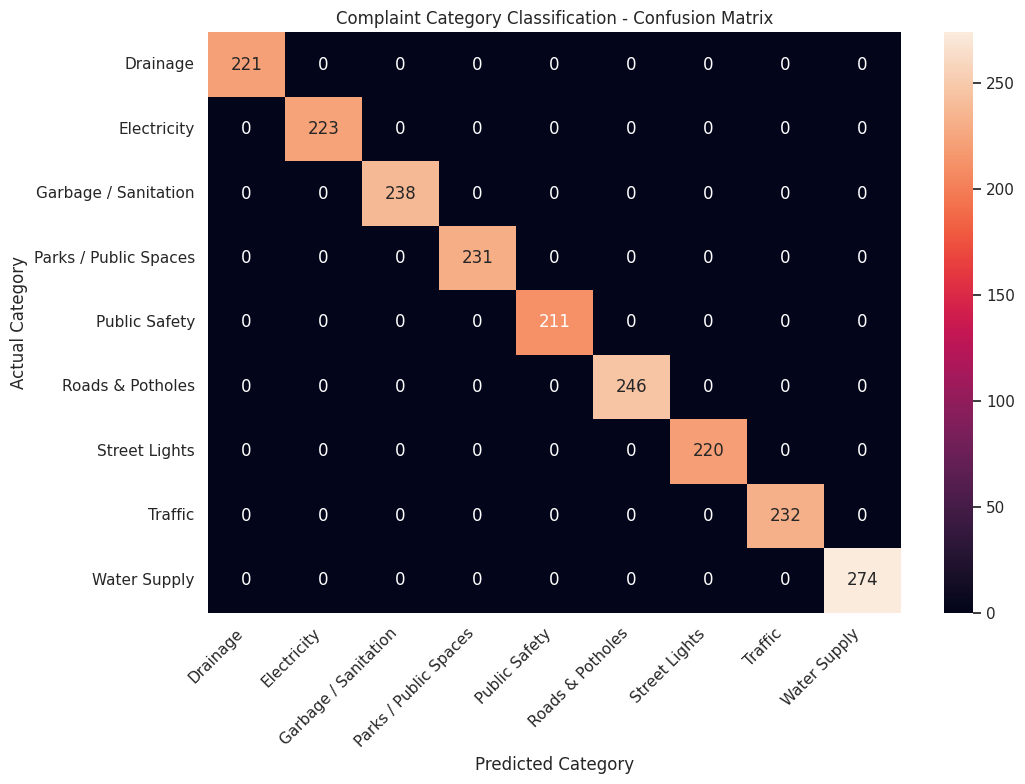

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(11, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=text_model.classes_,
    yticklabels=text_model.classes_
)

plt.title("Complaint Category Classification - Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Daily complaint counts by locality and category

daily_counts = (
    clean_df
    .groupby(["date", "locality", "category"])
    .size()
    .reset_index(name="complaint_count")
)

print("Daily records:", len(daily_counts))

display(daily_counts.head(20))

Daily records: 4121


,date,locality,category,complaint_count
0,2026-07-01,Sector 1,Electricity,1
1,2026-07-01,Sector 1,Garbage / Sanitation,1
2,2026-07-01,Sector 1,Public Safety,3
3,2026-07-01,Sector 1,Street Lights,1
4,2026-07-01,Sector 1,Traffic,3
5,2026-07-01,Sector 1,Water Supply,4
6,2026-07-01,Sector 12,Drainage,2
7,2026-07-01,Sector 12,Electricity,2
8,2026-07-01,Sector 12,Garbage / Sanitation,1
9,2026-07-01,Sector 12,Parks / Public Spaces,4


In [19]:
# Calculate historical baseline for each locality and category

baseline = (
    daily_counts
    .groupby(["locality", "category"])["complaint_count"]
    .agg(
        mean_count="mean",
        std_count="std"
    )
    .reset_index()
)

print("Baseline records:", len(baseline))

display(baseline.head(20))

Baseline records: 72


,locality,category,mean_count,std_count
0,Sector 1,Drainage,2.563636,1.424178
1,Sector 1,Electricity,2.305085,1.476882
2,Sector 1,Garbage / Sanitation,2.214286,1.216766
3,Sector 1,Parks / Public Spaces,2.366667,1.288366
4,Sector 1,Public Safety,2.224138,1.298354
5,Sector 1,Roads & Potholes,1.980769,1.111268
6,Sector 1,Street Lights,2.269841,1.608509
7,Sector 1,Traffic,2.750000,1.579798
8,Sector 1,Water Supply,2.403509,1.386924
9,Sector 12,Drainage,2.103448,1.194867


In [20]:
# Calculate anomaly Z-score for each locality-category-day

daily_anomalies = daily_counts.merge(
    baseline,
    on=["locality", "category"],
    how="left"
)

daily_anomalies["z_score"] = (
    (daily_anomalies["complaint_count"] - daily_anomalies["mean_count"])
    / daily_anomalies["std_count"]
)

print("Anomaly records:", len(daily_anomalies))

display(
    daily_anomalies.sort_values(
        "z_score",
        ascending=False
    ).head(20)
)

Anomaly records: 4121


,date,locality,category,complaint_count,mean_count,std_count,z_score
3910,2026-09-05,Sector 4,Roads & Potholes,28,3.776119,4.372160,5.540483
4051,2026-09-07,Ward 7,Street Lights,10,2.482143,1.501406,5.007210
3263,2026-08-25,Sector 12,Water Supply,52,5.614286,9.484225,4.890828
3965,2026-09-06,Sector 4,Roads & Potholes,25,3.776119,4.372160,4.854324
2720,2026-08-15,Ward 7,Water Supply,12,2.947368,1.874843,4.828474
3595,2026-08-31,Sector 1,Street Lights,10,2.269841,1.608509,4.805791
3320,2026-08-26,Sector 12,Water Supply,48,5.614286,9.484225,4.469075
3379,2026-08-27,Sector 12,Water Supply,47,5.614286,9.484225,4.363637
3696,2026-09-01,Ward 7,Garbage / Sanitation,34,3.618182,7.225190,4.204986
3755,2026-09-02,Ward 7,Garbage / Sanitation,34,3.618182,7.225190,4.204986


In [21]:
# Flag unusual complaint spikes

daily_anomalies["anomaly_level"] = np.select(
    [
        daily_anomalies["z_score"] >= 4,
        daily_anomalies["z_score"] >= 3,
        daily_anomalies["z_score"] >= 2
    ],
    [
        "Critical",
        "High",
        "Elevated"
    ],
    default="Normal"
)

# Keep only unusual observations
incidents = daily_anomalies[
    daily_anomalies["z_score"] >= 3
].copy()

print("Detected incidents:", len(incidents))

display(
    incidents.sort_values(
        "z_score",
        ascending=False
    ).head(30)
)

Detected incidents: 50


,date,locality,category,complaint_count,mean_count,std_count,z_score,anomaly_level
3910,2026-09-05,Sector 4,Roads & Potholes,28,3.776119,4.372160,5.540483,Critical
4051,2026-09-07,Ward 7,Street Lights,10,2.482143,1.501406,5.007210,Critical
3263,2026-08-25,Sector 12,Water Supply,52,5.614286,9.484225,4.890828,Critical
3965,2026-09-06,Sector 4,Roads & Potholes,25,3.776119,4.372160,4.854324,Critical
2720,2026-08-15,Ward 7,Water Supply,12,2.947368,1.874843,4.828474,Critical
3595,2026-08-31,Sector 1,Street Lights,10,2.269841,1.608509,4.805791,Critical
3320,2026-08-26,Sector 12,Water Supply,48,5.614286,9.484225,4.469075,Critical
3379,2026-08-27,Sector 12,Water Supply,47,5.614286,9.484225,4.363637,Critical
3755,2026-09-02,Ward 7,Garbage / Sanitation,34,3.618182,7.225190,4.204986,Critical
3696,2026-09-01,Ward 7,Garbage / Sanitation,34,3.618182,7.225190,4.204986,Critical


In [22]:
# Find recurring problems by locality and category

recurring = (
    incidents
    .groupby(["locality", "category"])
    .agg(
        incident_days=("date", "count"),
        total_complaints=("complaint_count", "sum"),
        max_z_score=("z_score", "max"),
        avg_z_score=("z_score", "mean")
    )
    .reset_index()
    .sort_values(
        ["incident_days", "max_z_score"],
        ascending=False
    )
)

print("Locality-category combinations with anomalies:")
print(len(recurring))

display(recurring.head(30))

Locality-category combinations with anomalies:
42


,locality,category,incident_days,total_complaints,max_z_score,avg_z_score
12,Sector 12,Water Supply,3,147,4.890828,4.574514
33,Ward 7,Garbage / Sanitation,3,99,4.204986,4.066581
22,Sector 4,Roads & Potholes,2,53,5.540483,5.197403
23,Sector 4,Water Supply,2,15,3.891856,3.540951
41,Ward 9,Water Supply,2,16,3.185093,3.185093
9,Sector 12,Roads & Potholes,2,16,3.144473,3.144473
35,Ward 7,Street Lights,1,10,5.007210,5.007210
37,Ward 7,Water Supply,1,12,4.828474,4.828474
4,Sector 1,Street Lights,1,10,4.805791,4.805791
6,Sector 12,Electricity,1,8,4.204054,4.204054


In [23]:
# Identify persistent problems with repeated anomalies

persistent_problems = (
    recurring[recurring["incident_days"] >= 2]
    .sort_values(
        ["incident_days", "max_z_score"],
        ascending=False
    )
)

print("Persistent locality-category problems:")
print(len(persistent_problems))

display(persistent_problems)


Persistent locality-category problems:
6


,locality,category,incident_days,total_complaints,max_z_score,avg_z_score
12,Sector 12,Water Supply,3,147,4.890828,4.574514
33,Ward 7,Garbage / Sanitation,3,99,4.204986,4.066581
22,Sector 4,Roads & Potholes,2,53,5.540483,5.197403
23,Sector 4,Water Supply,2,15,3.891856,3.540951
41,Ward 9,Water Supply,2,16,3.185093,3.185093
9,Sector 12,Roads & Potholes,2,16,3.144473,3.144473


In [24]:
# Calculate a combined problem severity score

persistent_problems["severity_score"] = (
    persistent_problems["incident_days"] * 2
    + persistent_problems["max_z_score"]
    + persistent_problems["avg_z_score"]
)

persistent_problems = persistent_problems.sort_values(
    "severity_score",
    ascending=False
).reset_index(drop=True)

print("Persistent problems ranked by severity:")
display(persistent_problems)

Persistent problems ranked by severity:


,locality,category,incident_days,total_complaints,max_z_score,avg_z_score,severity_score
0,Sector 12,Water Supply,3,147,4.890828,4.574514,15.465342
1,Sector 4,Roads & Potholes,2,53,5.540483,5.197403,14.737887
2,Ward 7,Garbage / Sanitation,3,99,4.204986,4.066581,14.271566
3,Sector 4,Water Supply,2,15,3.891856,3.540951,11.432806
4,Ward 9,Water Supply,2,16,3.185093,3.185093,10.370186
5,Sector 12,Roads & Potholes,2,16,3.144473,3.144473,10.288945


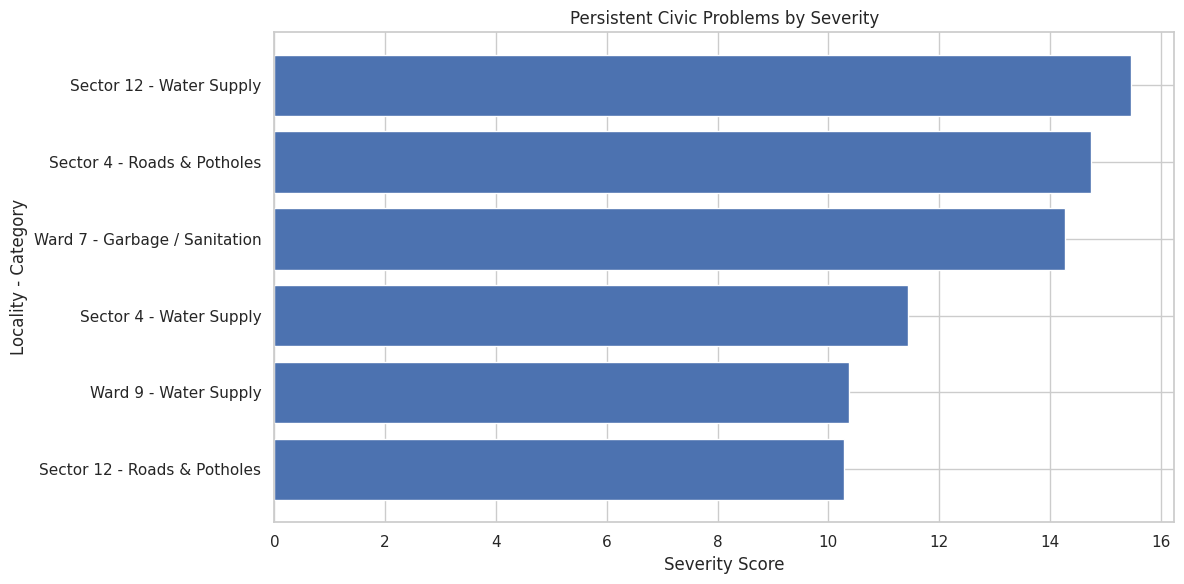

In [25]:
# Visualize persistent problems by severity

import matplotlib.pyplot as plt

labels = (
    persistent_problems["locality"]
    + " - "
    + persistent_problems["category"]
)

plt.figure(figsize=(12, 6))

plt.barh(
    labels,
    persistent_problems["severity_score"]
)

plt.xlabel("Severity Score")
plt.ylabel("Locality - Category")
plt.title("Persistent Civic Problems by Severity")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
# Analyze daily complaint trends

daily_trend = (
    clean_df
    .groupby("date")
    .agg(
        total_complaints=("incident_id", "count"),
        open_complaints=("is_open", "sum"),
        categories=("category", "nunique"),
        localities=("locality", "nunique")
    )
    .reset_index()
    .sort_values("date")
)

print("Daily complaint records:", len(daily_trend))

display(daily_trend.head(10))

Daily complaint records: 70


,date,total_complaints,open_complaints,categories,localities
0,2026-07-01,138,90,9,8
1,2026-07-02,153,100,9,8
2,2026-07-03,141,97,9,8
3,2026-07-04,152,100,9,8
4,2026-07-05,163,112,9,8
5,2026-07-06,135,89,9,8
6,2026-07-07,138,92,9,8
7,2026-07-08,155,110,9,8
8,2026-07-09,146,90,9,8
9,2026-07-10,151,95,9,8


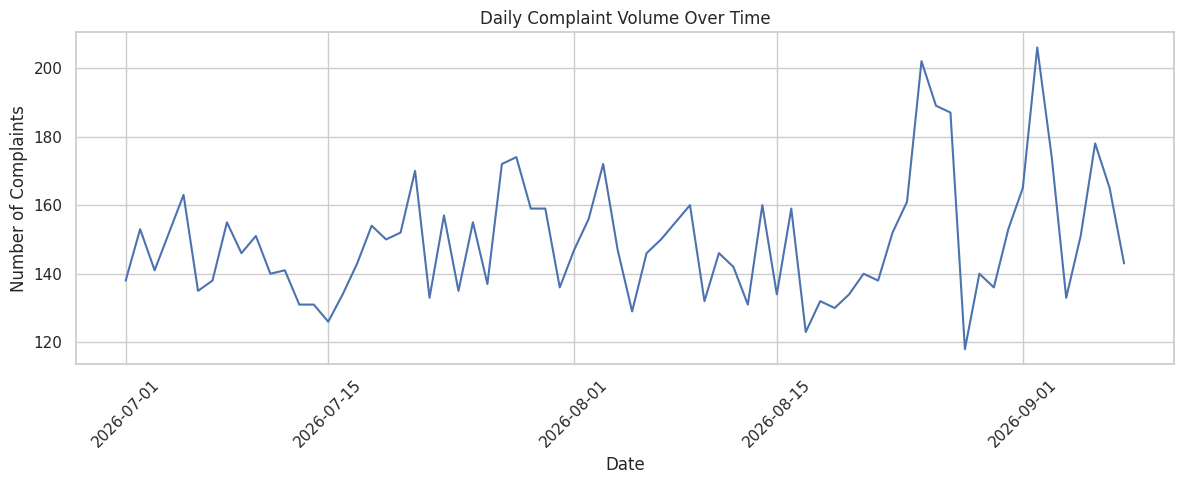

In [27]:
# Plot daily complaint volume

plt.figure(figsize=(12, 5))

plt.plot(
    daily_trend["date"],
    daily_trend["total_complaints"]
)

plt.xlabel("Date")
plt.ylabel("Number of Complaints")
plt.title("Daily Complaint Volume Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Analyze complaint volume by category

category_summary = (
    clean_df
    .groupby("category")
    .agg(
        total_complaints=("incident_id", "count"),
        affected_localities=("locality", "nunique"),
        avg_daily_complaints=("incident_id", "count")
    )
    .reset_index()
)

# Calculate percentage of total complaints
category_summary["percentage"] = (
    category_summary["total_complaints"]
    / category_summary["total_complaints"].sum()
    * 100
)

category_summary = category_summary.sort_values(
    "total_complaints",
    ascending=False
)

display(category_summary)

,category,total_complaints,affected_localities,avg_daily_complaints,percentage
8,Water Supply,1368,8,1368,13.057173
5,Roads & Potholes,1230,8,1230,11.740002
2,Garbage / Sanitation,1189,8,1189,11.348669
7,Traffic,1160,8,1160,11.071872
3,Parks / Public Spaces,1152,8,1152,10.995514
1,Electricity,1113,8,1113,10.623270
0,Drainage,1106,8,1106,10.556457
6,Street Lights,1102,8,1102,10.518278
4,Public Safety,1057,8,1057,10.088766


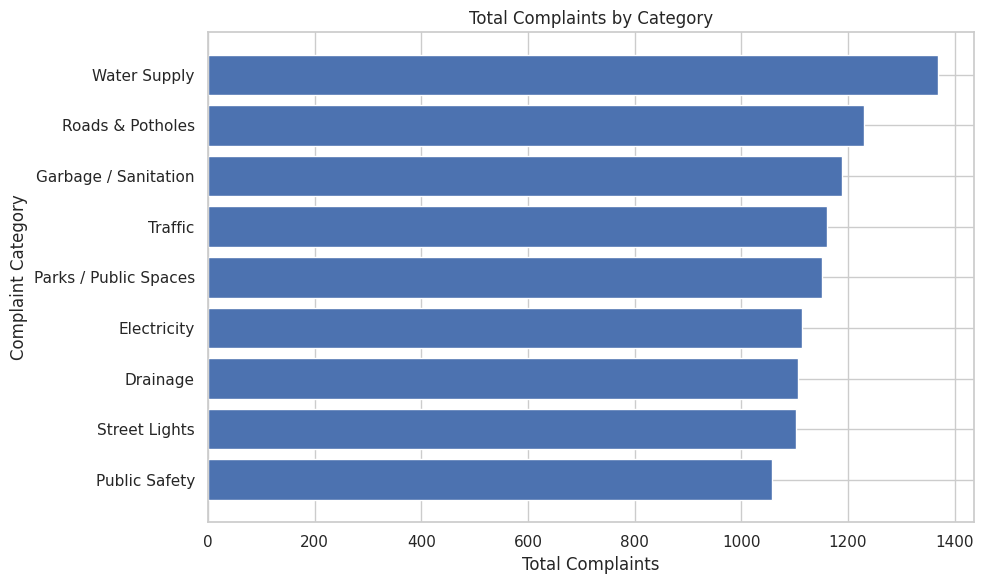

In [29]:
# Plot complaint volume by category

plt.figure(figsize=(10, 6))

plt.barh(
    category_summary["category"],
    category_summary["total_complaints"]
)

plt.xlabel("Total Complaints")
plt.ylabel("Complaint Category")
plt.title("Total Complaints by Category")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
# Analyze complaint volume by locality

locality_summary = (
    clean_df
    .groupby("locality")
    .agg(
        total_complaints=("incident_id", "count"),
        categories=("category", "nunique")
    )
    .reset_index()
)

locality_summary["percentage"] = (
    locality_summary["total_complaints"]
    / locality_summary["total_complaints"].sum()
    * 100
)

locality_summary = locality_summary.sort_values(
    "total_complaints",
    ascending=False
)

display(locality_summary)

,locality,total_complaints,categories,percentage
1,Sector 12,1452,9,13.858929
6,Ward 7,1329,9,12.684929
7,Ward 9,1321,9,12.608571
2,Sector 15,1317,9,12.570392
3,Sector 4,1304,9,12.446311
4,Sector 8,1273,9,12.150425
5,Ward 11,1261,9,12.035888
0,Sector 1,1220,9,11.644555


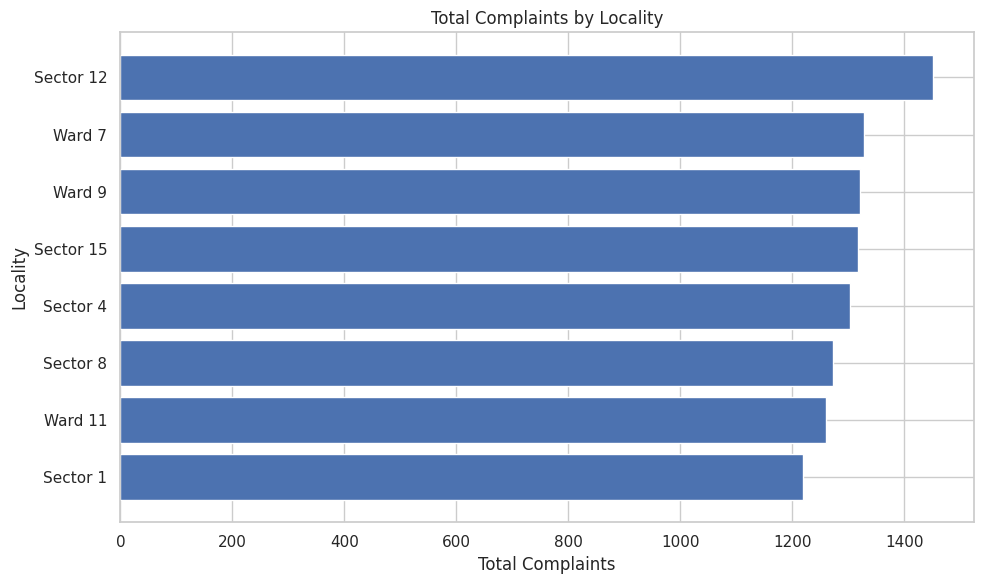

In [31]:
# Plot complaint volume by locality

plt.figure(figsize=(10, 6))

plt.barh(
    locality_summary["locality"],
    locality_summary["total_complaints"]
)

plt.xlabel("Total Complaints")
plt.ylabel("Locality")
plt.title("Total Complaints by Locality")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

category,Drainage,Electricity,Garbage / Sanitation,Parks / Public Spaces,Public Safety,Roads & Potholes,Street Lights,Traffic,Water Supply
locality,,,,,,,,,
Sector 1,141,136,124,142,129,103,143,165,137
Sector 12,122,117,132,161,131,142,120,134,393
Sector 15,141,161,143,150,116,156,169,146,135
Sector 4,131,124,143,113,136,253,136,133,135
Sector 8,138,143,167,159,108,167,133,135,123
Ward 11,136,154,144,125,127,144,139,155,137
Ward 7,153,125,199,134,142,138,139,131,168
Ward 9,144,153,137,168,168,127,123,161,140


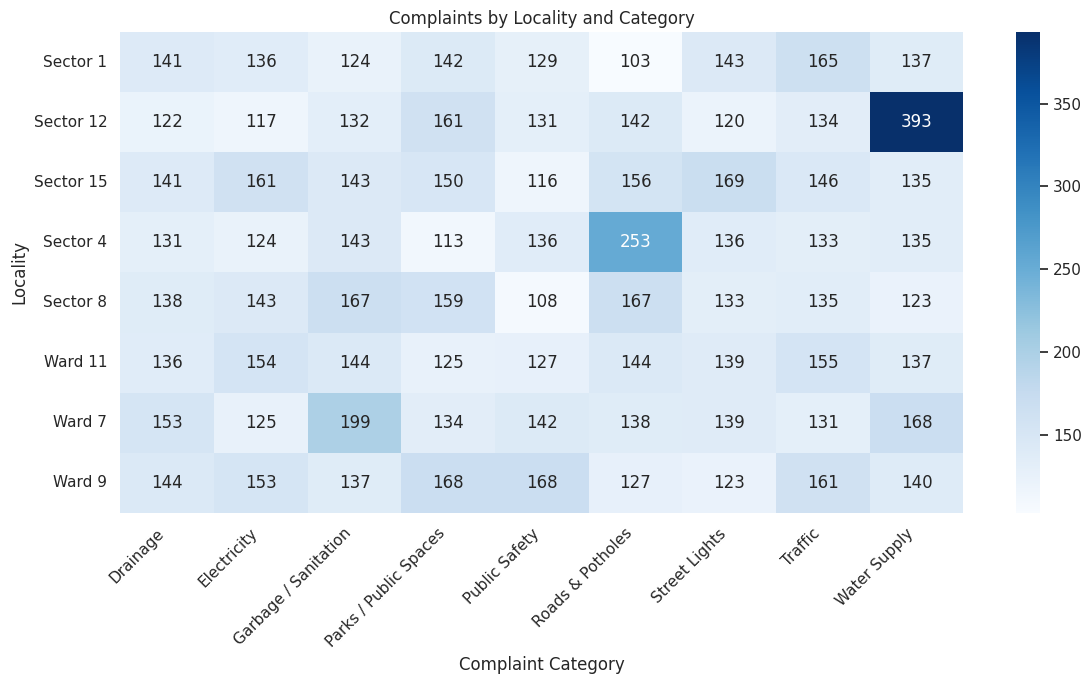

In [32]:
# Locality × Category complaint heatmap

locality_category = pd.crosstab(
    clean_df["locality"],
    clean_df["category"]
)

display(locality_category)

# Plot heatmap

plt.figure(figsize=(12, 7))

sns.heatmap(
    locality_category,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Complaints by Locality and Category")
plt.xlabel("Complaint Category")
plt.ylabel("Locality")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [33]:
# Find the most common complaint category in each locality

top_category_by_locality = (
    locality_category
    .idxmax(axis=1)
    .reset_index()
)

top_category_by_locality.columns = [
    "locality",
    "top_complaint_category"
]

top_category_by_locality["complaint_count"] = [
    locality_category.loc[locality, category]
    for locality, category
    in zip(
        top_category_by_locality["locality"],
        top_category_by_locality["top_complaint_category"]
    )
]

display(top_category_by_locality)

,locality,top_complaint_category,complaint_count
0,Sector 1,Traffic,165
1,Sector 12,Water Supply,393
2,Sector 15,Street Lights,169
3,Sector 4,Roads & Potholes,253
4,Sector 8,Garbage / Sanitation,167
5,Ward 11,Traffic,155
6,Ward 7,Garbage / Sanitation,199
7,Ward 9,Parks / Public Spaces,168


In [34]:
# Identify the most problematic complaint categories

category_priority = (
    clean_df.groupby("category")
    .agg(
        total_complaints=("incident_id", "count"),
        affected_localities=("locality", "nunique")
    )
    .sort_values("total_complaints", ascending=False)
    .reset_index()
)

display(category_priority)

,category,total_complaints,affected_localities
0,Water Supply,1368,8
1,Roads & Potholes,1230,8
2,Garbage / Sanitation,1189,8
3,Traffic,1160,8
4,Parks / Public Spaces,1152,8
5,Electricity,1113,8
6,Drainage,1106,8
7,Street Lights,1102,8
8,Public Safety,1057,8


In [35]:
# Identify the most problematic localities

locality_priority = (
    clean_df.groupby("locality")
    .agg(
        total_complaints=("incident_id", "count"),
        categories=("category", "nunique")
    )
    .sort_values("total_complaints", ascending=False)
    .reset_index()
)

display(locality_priority)


,locality,total_complaints,categories
0,Sector 12,1452,9
1,Ward 7,1329,9
2,Ward 9,1321,9
3,Sector 15,1317,9
4,Sector 4,1304,9
5,Sector 8,1273,9
6,Ward 11,1261,9
7,Sector 1,1220,9


In [36]:
# Find high-volume locality-category combinations

locality_category_priority = (
    clean_df.groupby(["locality", "category"])
    .agg(total_complaints=("incident_id", "count"))
    .sort_values("total_complaints", ascending=False)
    .reset_index()
)

display(locality_category_priority.head(20))

,locality,category,total_complaints
0,Sector 12,Water Supply,393
1,Sector 4,Roads & Potholes,253
2,Ward 7,Garbage / Sanitation,199
3,Sector 15,Street Lights,169
4,Ward 7,Water Supply,168
5,Ward 9,Public Safety,168
6,Ward 9,Parks / Public Spaces,168
7,Sector 8,Garbage / Sanitation,167
8,Sector 8,Roads & Potholes,167
9,Sector 1,Traffic,165


In [37]:
# Final key insights

print("FINAL DATASET INSIGHTS")
print("=" * 50)

print(f"Total valid records: {len(clean_df):,}")
print(f"Total complaints: {clean_df['incident_id'].nunique():,}")
print(f"Categories: {clean_df['category'].nunique()}")
print(f"Localities: {clean_df['locality'].nunique()}")

print("\nHighest complaint category:")
print(category_priority.iloc[0][["category", "total_complaints"]])

print("\nHighest complaint locality:")
print(locality_priority.iloc[0][["locality", "total_complaints"]])

print("\nMost severe recurring problem:")
print(persistent_problems.iloc[0][
    ["locality", "category", "incident_days", "total_complaints", "severity_score"]
])

FINAL DATASET INSIGHTS
Total valid records: 10,477
Total complaints: 10,477
Categories: 9
Localities: 8

Highest complaint category:
category            Water Supply
total_complaints            1368
Name: 0, dtype: object

Highest complaint locality:
locality            Sector 12
total_complaints         1452
Name: 0, dtype: object

Most severe recurring problem:
locality               Sector 12
category            Water Supply
incident_days                  3
total_complaints             147
severity_score         15.465342
Name: 0, dtype: object


ML PART

In [38]:
# Prepare data for machine learning

model_df = daily_trend.copy()

model_df["date"] = pd.to_datetime(model_df["date"])

model_df["day"] = model_df["date"].dt.day
model_df["month"] = model_df["date"].dt.month
model_df["weekday"] = model_df["date"].dt.weekday
model_df["week"] = model_df["date"].dt.isocalendar().week.astype(int)

X = model_df[
    ["day", "month", "weekday", "week", "open_complaints",
     "categories", "localities"]
]

y = model_df["total_complaints"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,day,month,weekday,week,open_complaints,categories,localities
0,1,7,2,27,90,9,8
1,2,7,3,27,100,9,8
2,3,7,4,27,97,9,8
3,4,7,5,27,100,9,8
4,5,7,6,27,112,9,8


Target:


0    138
1    153
2    141
3    152
4    163
Name: total_complaints, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


In [40]:
def evaluate_model(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"R² % : {r2 * 100:.2f}%")

evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Random Forest", y_test, rf_pred)


Linear Regression
----------------------------------------
MAE  : 5.81
MSE  : 46.68
RMSE : 6.83
R²   : 0.7886
R² % : 78.86%

Random Forest
----------------------------------------
MAE  : 6.36
MSE  : 68.67
RMSE : 8.29
R²   : 0.6890
R² % : 68.90%


,Actual,Predicted
0,157,145.052171
1,138,138.144663
2,130,142.049922
3,163,159.692853
4,161,153.813831
5,150,157.062237
6,140,145.536337
7,172,179.625292
8,134,133.188339
9,131,135.672720


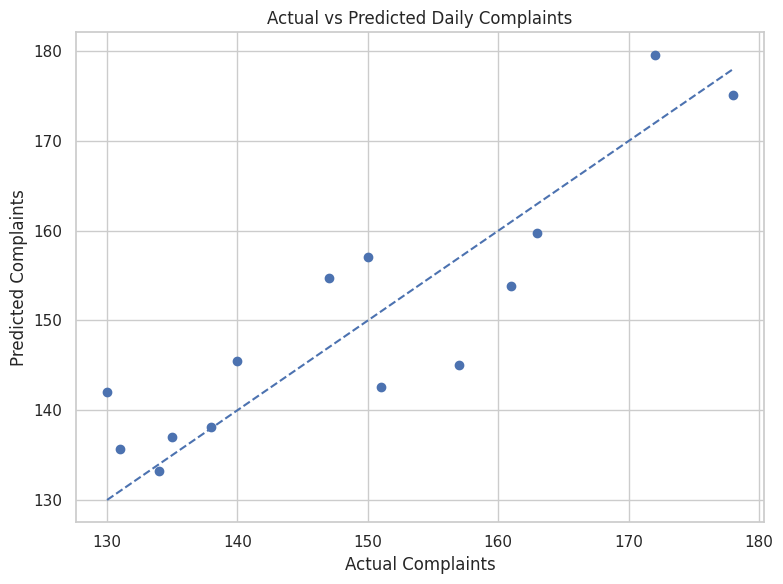

In [41]:
# Compare actual and predicted complaint counts

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": linear_pred
})

display(comparison.head(15))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred)

plt.xlabel("Actual Complaints")
plt.ylabel("Predicted Complaints")
plt.title("Actual vs Predicted Daily Complaints")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

# Try degree 2 polynomial regression
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

poly_pred = poly_model.predict(X_test)

evaluate_model("Polynomial Regression (Degree 2)", y_test, poly_pred)


Polynomial Regression (Degree 2)
----------------------------------------
MAE  : 6.50
MSE  : 70.14
RMSE : 8.37
R²   : 0.6823
R² % : 68.23%


In [43]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

evaluate_model("Gradient Boosting", y_test, gb_pred)


Gradient Boosting
----------------------------------------
MAE  : 6.87
MSE  : 74.17
RMSE : 8.61
R²   : 0.6641
R² % : 66.41%


In [44]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.05,
    max_leaf_nodes=15,
    random_state=42
)

hgb_model.fit(X_train, y_train)

hgb_pred = hgb_model.predict(X_test)

evaluate_model("Hist Gradient Boosting", y_test, hgb_pred)


Hist Gradient Boosting
----------------------------------------
MAE  : 7.26
MSE  : 76.57
RMSE : 8.75
R²   : 0.6532
R² % : 65.32%


In [45]:
# Prepare daily data for time-series features

model_df = daily_trend.copy()
model_df["date"] = pd.to_datetime(model_df["date"])
model_df = model_df.sort_values("date").reset_index(drop=True)

# Calendar features
model_df["day"] = model_df["date"].dt.day
model_df["month"] = model_df["date"].dt.month
model_df["weekday"] = model_df["date"].dt.weekday
model_df["week"] = model_df["date"].dt.isocalendar().week.astype(int)

# Lag features
model_df["lag_1"] = model_df["total_complaints"].shift(1)
model_df["lag_7"] = model_df["total_complaints"].shift(7)
model_df["rolling_7"] = model_df["total_complaints"].shift(1).rolling(7).mean()

# Remove rows created by lagging
model_df = model_df.dropna().reset_index(drop=True)

print(f"Prepared {len(model_df)} daily records with calendar and lag features.")
display(model_df.head(10))

Prepared 63 daily records with calendar and lag features.


,date,total_complaints,open_complaints,categories,localities,day,month,weekday,week,lag_1,lag_7,rolling_7
0,2026-07-08,155,110,9,8,8,7,2,28,138.0,138.0,145.714286
1,2026-07-09,146,90,9,8,9,7,3,28,155.0,153.0,148.142857
2,2026-07-10,151,95,9,8,10,7,4,28,146.0,141.0,147.142857
3,2026-07-11,140,98,9,8,11,7,5,28,151.0,152.0,148.571429
4,2026-07-12,141,95,9,8,12,7,6,28,140.0,163.0,146.857143
5,2026-07-13,131,88,9,8,13,7,0,29,141.0,135.0,143.714286
6,2026-07-14,131,97,9,8,14,7,1,29,131.0,138.0,143.142857
7,2026-07-15,126,85,9,8,15,7,2,29,131.0,155.0,142.142857
8,2026-07-16,134,88,9,8,16,7,3,29,126.0,146.0,138.000000
9,2026-07-17,143,104,9,8,17,7,4,29,134.0,151.0,136.285714


In [46]:
# Features and target

features = [
    "day",
    "month",
    "weekday",
    "week",
    "open_complaints",
    "categories",
    "localities",
    "lag_1",
    "lag_7",
    "rolling_7"
]

X = model_df[features]
y = model_df["total_complaints"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,day,month,weekday,week,open_complaints,categories,localities,lag_1,lag_7,rolling_7
0,8,7,2,28,110,9,8,138.0,138.0,145.714286
1,9,7,3,28,90,9,8,155.0,153.0,148.142857
2,10,7,4,28,95,9,8,146.0,141.0,147.142857
3,11,7,5,28,98,9,8,151.0,152.0,148.571429
4,12,7,6,28,95,9,8,140.0,163.0,146.857143



Target:


0    155
1    146
2    151
3    140
4    141
Name: total_complaints, dtype: int64

In [47]:
# Chronological train-test split

split = int(len(model_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 50
Testing rows: 13


In [48]:
from sklearn.linear_model import LinearRegression

linear_lag_model = LinearRegression()

linear_lag_model.fit(X_train, y_train)

linear_lag_pred = linear_lag_model.predict(X_test)

evaluate_model(
    "Linear Regression + Lag Features",
    y_test,
    linear_lag_pred
)


Linear Regression + Lag Features
----------------------------------------
MAE  : 5.63
MSE  : 44.29
RMSE : 6.65
R²   : 0.9204
R² % : 92.04%


In [50]:
import joblib

joblib.dump(
    {
        "model": linear_lag_model,
        "features": features
    },
    "complaint_prediction_model.pkl"
)

['complaint_prediction_model.pkl']